# DecodeLabs AI Project 2 — Data Classification Using KNN

**Project goal:** Build a supervised learning classification model using the Iris dataset and K-Nearest Neighbors (KNN).

This notebook covers the full required pipeline:

1. Load and understand a small dataset  
2. Explore features and target classes  
3. Split data into training and testing sets  
4. Apply feature scaling using `StandardScaler`  
5. Train a KNN classification model  
6. Tune the value of **K**  
7. Evaluate the model using accuracy, confusion matrix, precision, recall, and F1-score  
8. Test the model on a new custom flower sample  
9. Save the trained model for future deployment


## Cell 1 — Import Libraries

In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import joblib

RANDOM_STATE = 42
print('Libraries imported successfully!')

Libraries imported successfully!


## Cell 3 — Load the Iris Dataset

The Iris dataset has:

- **150 samples**
- **4 numerical features**
- **3 classes**: Setosa, Versicolor, Virginica


In [21]:
iris = load_iris()

# Create a clean DataFrame
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(iris.data, columns=feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({i: name for i, name in enumerate(target_names)})

print('Dataset loaded successfully!')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully!
Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Cell 5 — Understand the Dataset

In [22]:
print('Dataset Information:')
print('-' * 50)
df.info()

print('\\nMissing Values:')
print(df.isnull().sum())

print('\\nClass Distribution:')
print(df['species'].value_counts())

print('\\nStatistical Summary:')
df.describe()

Dataset Information:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
\nMissing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64
\nClass Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
\nStatistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Cell 6 — Visualize Basic Dataset Patterns

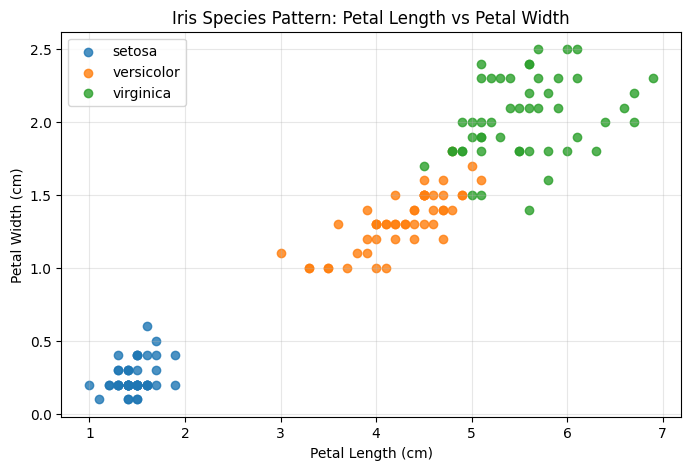

In [23]:
# Scatter plot using two important features
plt.figure(figsize=(8, 5))

for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=species,
        alpha=0.8
    )

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Species Pattern: Petal Length vs Petal Width')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Cell 7 — Separate Features and Target

- `X` contains the input features.
- `y` contains the output class labels.


In [24]:
X = df[feature_names]
y = df['target']

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)
print('\\nFeatures used:')
print(feature_names)
print('\\nTarget classes:')
for index, name in enumerate(target_names):
    print(index, '->', name)

Feature matrix shape: (150, 4)
Target vector shape: (150,)
\nFeatures used:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
\nTarget classes:
0 -> setosa
1 -> versicolor
2 -> virginica


## Cell 8 — Train-Test Split

We split the dataset into:

- **80% training data** for learning patterns
- **20% testing data** for validation

`stratify=y` keeps the class distribution balanced in both training and testing data.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])
print('\\nTraining class distribution:')
print(pd.Series(y_train).map({i: name for i, name in enumerate(target_names)}).value_counts())
print('\\nTesting class distribution:')
print(pd.Series(y_test).map({i: name for i, name in enumerate(target_names)}).value_counts())

Training samples: 120
Testing samples: 30
\nTraining class distribution:
target
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64
\nTesting class distribution:
target
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


## Cell 9 — Feature Scaling

KNN uses distance. If features are on different scales, distance calculation can become biased.  
So we use `StandardScaler`, which converts features to approximately mean 0 and standard deviation 1.


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Before scaling:')
print(pd.DataFrame(X_train, columns=feature_names).head())

print('\\nAfter scaling:')
print(pd.DataFrame(X_train_scaled, columns=feature_names).head())

Before scaling:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
8                  4.4               2.9                1.4               0.2
106                4.9               2.5                4.5               1.7
76                 6.8               2.8                4.8               1.4
9                  4.9               3.1                1.5               0.1
89                 5.5               2.5                4.0               1.3
\nAfter scaling:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -1.721568         -0.332101          -1.345722         -1.323276
1          -1.124492         -1.227655           0.414505          0.651763
2           1.144395         -0.555990           0.584850          0.256755
3          -1.124492          0.115676          -1.288941         -1.454945
4          -0.408002         -1.227655           0.130598          0.125086


## Cell 10 — Train the First KNN Model

We begin with `k = 5`, which is a common starting value.


In [27]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print('KNN model trained successfully with k = 5')

KNN model trained successfully with k = 5


## Cell 11 — Make Predictions

In [28]:
y_pred = knn.predict(X_test_scaled)

results_df = pd.DataFrame({
    'Actual': [target_names[i] for i in y_test],
    'Predicted': [target_names[i] for i in y_pred]
})

print('Predictions generated successfully!')
results_df.head(10)

Predictions generated successfully!


,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


## Cell 12 — Evaluate the Model

We check more than accuracy because accuracy alone can sometimes be misleading, especially for imbalanced datasets.


In [29]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print('Model Evaluation Scores')
print('-' * 40)
print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')

print('\\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

Model Evaluation Scores
----------------------------------------
Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1 Score : 0.9327
\nDetailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## Cell 13 — Confusion Matrix

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


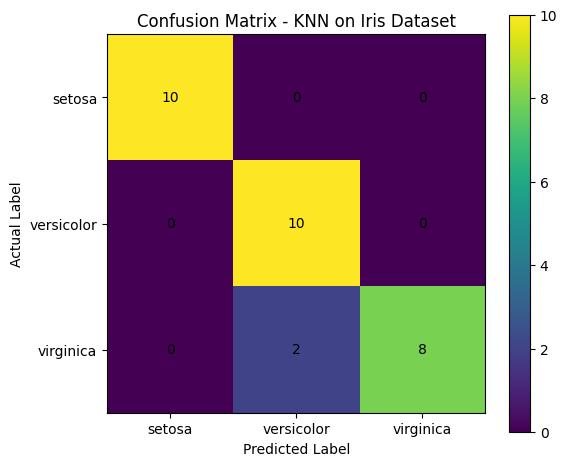

In [30]:
cm = confusion_matrix(y_test, y_pred)

print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title('Confusion Matrix - KNN on Iris Dataset')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(ticks=np.arange(len(target_names)), labels=target_names)
plt.yticks(ticks=np.arange(len(target_names)), labels=target_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

## Cell 14 — Tune K Value

KNN performance depends on the value of **K**.

- Very small K can overfit.
- Very large K can underfit.
- We test multiple K values and select the best one based on test accuracy.


Best K: 1
Best Accuracy: 0.9667


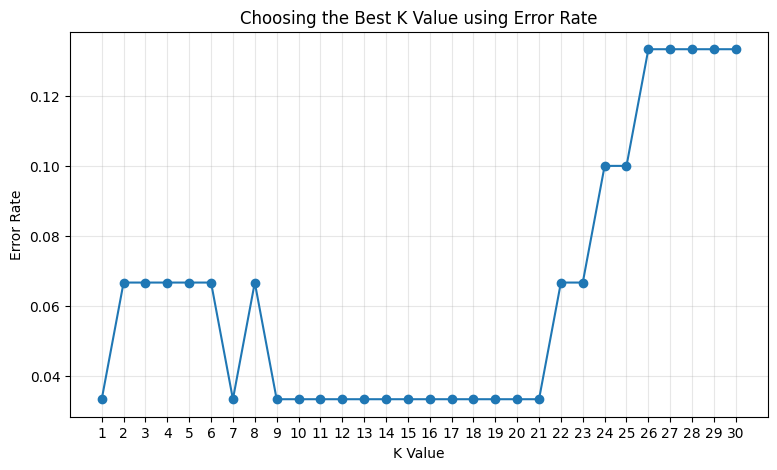

In [31]:
k_values = range(1, 31)
accuracy_scores = []
error_rates = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    accuracy_scores.append(acc)
    error_rates.append(1 - acc)

best_k = list(k_values)[int(np.argmax(accuracy_scores))]
best_accuracy = max(accuracy_scores)

print('Best K:', best_k)
print(f'Best Accuracy: {best_accuracy:.4f}')

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), error_rates, marker='o')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Choosing the Best K Value using Error Rate')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

## Cell 15 — Train Final Model with Best K

We now train the final model using the best K value found above.


In [32]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

final_predictions = final_knn.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions, average='weighted')

print('Final Model Results')
print('-' * 40)
print('Final K:', best_k)
print(f'Final Accuracy: {final_accuracy:.4f}')
print(f'Final F1 Score: {final_f1:.4f}')

Final Model Results
----------------------------------------
Final K: 1
Final Accuracy: 0.9667
Final F1 Score: 0.9666


## Cell 16 — Build a Clean Pipeline

A pipeline keeps scaling and KNN together. This is useful for deployment because you do not have to manually scale new input every time.


In [33]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

knn_pipeline.fit(X_train, y_train)
pipeline_predictions = knn_pipeline.predict(X_test)

print('Pipeline trained successfully!')
print(f'Pipeline Accuracy: {accuracy_score(y_test, pipeline_predictions):.4f}')
print(f'Pipeline F1 Score: {f1_score(y_test, pipeline_predictions, average="weighted"):.4f}')

Pipeline trained successfully!
Pipeline Accuracy: 0.9667
Pipeline F1 Score: 0.9666


## Cell 17 — Test the Model with New Data

Example input format:

`[sepal length, sepal width, petal length, petal width]`


In [34]:
# Example custom flower sample
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=feature_names
)

predicted_class = knn_pipeline.predict(new_flower)[0]
predicted_species = target_names[predicted_class]

print('New flower measurements:')
print(new_flower)
print('\\nPredicted species:', predicted_species)

New flower measurements:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
\nPredicted species: setosa


## Cell 18 — Save the Model for Deployment

This saves the complete pipeline including both scaling and KNN classifier.


In [35]:
model_filename = 'knn_iris_model.joblib'
joblib.dump(knn_pipeline, model_filename)
print(f'Model saved successfully as: {model_filename}')

Model saved successfully as: knn_iris_model.joblib


## Cell 19 — Load Saved Model and Predict Again

This confirms that the saved model works correctly after loading.


In [36]:
loaded_model = joblib.load(model_filename)
loaded_prediction = loaded_model.predict(new_flower)[0]

print('Loaded model prediction:', target_names[loaded_prediction])

Loaded model prediction: setosa


## Final Conclusion

This project successfully implements a complete supervised learning classification pipeline using KNN:

- Dataset loaded and explored
- Data split into training/testing sets
- Features scaled using StandardScaler
- KNN model trained
- K value tuned
- Model evaluated using confusion matrix and F1-score
- Final pipeline saved for deployment
